In [1]:
import os
from typing import Literal
from typing_extensions import TypedDict

# LangChain core
from langchain_core.messages import HumanMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool
from langchain.tools import tool
from langchain_core.output_parsers import StrOutputParser
from langchain.agents import create_react_agent, load_tools

# LangGraph
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from langgraph.graph import MessagesState
from langgraph.prebuilt import create_react_agent

# LangChain OpenAI
from langchain_openai import ChatOpenAI

# LangChain Community tools
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.utilities.sql_database import SQLDatabase

# LangChain Experimental
from typing import TypedDict
import gradio as gr


In [2]:
with open("APPI OPENAI.txt") as archivo:
  apikey_OPENAI = archivo.read()
os.environ["OPENAI_API_KEY"] = apikey_OPENAI

with open("postgrest.txt") as archivo:
  uribd = archivo.read()

with open("APPI TAVILY.txt") as archivo:
  apikey_TAVILY = archivo.read()
os.environ["TAVILY_API_KEY"] = apikey_TAVILY


In [3]:
model = ChatOpenAI(model="gpt-4-turbo", temperature=0, verbose=True,max_tokens=3000)
tavily_tool = TavilySearchResults(max_results=5)
arxiv_tool = load_tools(["arxiv"], llm=model)[0]
db_data = SQLDatabase.from_uri(uribd)
memory = MemorySaver()

In [4]:
# Agentes especializados
members = ["TENDENCIASagente","SQLagente","SELECCIONagente"]

options = members + ["FINISH"]

system_prompt = (
    """Eres un supervisor encargado de gestionar una conversación entre los siguientes agentes: {members}.
    Dada la solicitud del usuario, responde con el agente que debe actuar a continuación.
    Cada agente realizará una tarea y responderá con sus resultados y estado.
    Cuando terminen, responde con FINISH."""
)

class Router(TypedDict):
    """Agente al que se debe redirigir el siguiente paso. Si no se necesitan más agentes, redirigir a FINISH."""
    next: Literal[*options] 



class State(MessagesState):
    next: str

# nodo supervisor 
def supervisor_node(state: State) -> Command[Literal[*members, "__end__"]]:
    messages = [
        {"role": "system", "content": system_prompt},
    ] + state["messages"]
    response = model.with_structured_output(Router).invoke(messages) 
    goto = response["next"]
    if goto == "FINISH":
        goto = END

    return Command(goto=goto, update={"next": goto})

In [5]:
# Agente tendencias 
tendencia_agente = create_react_agent(
    model, tools=[arxiv_tool], 
    prompt="""
    Eres un agente investigador experto en analizar artículos recientes de Arxiv para identificar subcampos emergentes específicas que están ganando relevancia profesional.

    Tu tarea es buscar y recomendar una lista final de 3 subcampos altamente relevantes utilizando fuentes como Arxiv.

    Para cada subcampo, proporciona:
    - Nombre del subcampo
    - Razon de su relevancia explicado en 10 palabras

    La salida debe ser [nombre subcampo: razon de relevancia, nombre subcampo : razon de relevancia]

    Evita listas genéricas y conclusiones vagas.
    """

)

# nodo tendencia
def tendencia_node(state: State) -> Command[Literal["supervisor"]]: # solo puede ir luego al supervisor
    result = tendencia_agente.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="TENDENCIASagente")
            ]
        },
        goto="supervisor",
    )

In [6]:
seleccion_prompt = ChatPromptTemplate.from_template("""
Eres un asesor académico y tu tarea es alinear programas educativos con las siguientes tendencias identificadas:

Tendencias:
{tendencias}

Programas Educativos Disponibles:
{programas}

Para cada tendencia, selecciona los programas más relacionados y explica brevemente por qué están alineados.

Formato de salida:

Tendencia: [nombre]
- Programa A: razón
- Programa B: razón
...
""")


def seleccion_node(state: State) -> Command[Literal["supervisor"]]:
    # Obtener el mensaje del agente de tendencias
    tendencias_msg = next((msg for msg in state["messages"] if msg.name == "TENDENCIASagente"), None)
    tendencias = tendencias_msg.content if tendencias_msg else "No se encontraron tendencias."

    # Obtener el mensaje del agente SQL
    sql_msg = next((msg for msg in state["messages"] if msg.name == "SQLagente"), None)
    programas = sql_msg.content if sql_msg else "No se encontraron programas educativos."

    # Construir prompt
    prompt_text = seleccion_prompt.format_messages(
        tendencias=tendencias,
        programas=programas
    )
    result = model.invoke(prompt_text)

    return Command(
        update={"messages": [HumanMessage(content=result.content, name="SELECCIONagente")]},
        goto="supervisor",
    )


In [7]:
# Agente SQL

@tool
def get_schema() -> str:
  "Herramienta para recuperar el esquema de la base de datos"
  return db_data.get_table_info()

promptsql = ChatPromptTemplate.from_template("""
Basandonos en el esquema de tabla siguiente, escribe una consulta SQL que responda a la pregunta del usuario:
{schema}
El presupuesto promedio mensual se obtiene al calcular la diferencia total entre todos los ingresos y todos los gastos, y luego dividir ese resultado entre 12 meses.
El costo mensual total de una combinacion de programas educativos es la suma de la cuota mensual de cada programa educativo que forma parte de una misma combinacion
Pregunta: {question}
Sql Query:
""")


sqlchain = (
    promptsql
    | model.bind(stop=["\nSQLResult:"])
    | StrOutputParser()
)

@tool
def generar_sql(table_schema: str, question: str) -> str:
    """Genera una consulta SQL a partir del esquema"""
    return sqlchain.invoke({"schema": table_schema, "question": question})


@tool
def run_query(query:str) -> str:
    """Herramienta que ejecuta una consulta SQL en la base de datos"""
    return db_data.run(query)

promptsqlquery = ChatPromptTemplate.from_template(
    """
    Basandonos en el esquema de tabla inferior, pregunta, SQL Query y Respuesta, escribe una respuesta en lenguaje natural:
    {schema}

    Pregunta: {question}
    Sql Query: {query}
    SQL Respuesta: {response}

    """)

sqlnatural_chain = (
     promptsqlquery
    | model
    | StrOutputParser()
)

@tool
def generar_respuesta(table_schema: str, question: str, sql_query: str, response: str) -> str:
    """Genera una respuesta en lenguaje natural tomando el esquema, la consulta, la query, y la respuesta de la ejecucion de la query"""
    return sqlnatural_chain.invoke({"schema": table_schema, "question": question, "sql_query":sql_query, "response":response})


prompt = ChatPromptTemplate.from_messages(
    [
        ("system", """ Eres un asistente de consultas SQL. Tu única función es generar y ejecutar consultas relacionadas con los ingresos, gastos y programas del usuario.
        Limítate a responder con datos precisos. 
        """),

     ("human", "{messages}"),

     ]
)

toolkit = [get_schema,generar_sql,run_query,generar_respuesta]
sql_agente = create_react_agent(model, toolkit, checkpointer=memory, prompt=prompt)

# nodo sql
def sql_node(state: State) -> Command[Literal["supervisor"]]: 
    result = sql_agente.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="SQLagente")
            ]
        },
        goto="supervisor",
    )

In [8]:
builder = StateGraph(State)
builder.add_edge(START, "supervisor")
builder.add_node("supervisor", supervisor_node)
builder.add_node("TENDENCIASagente", tendencia_node)
builder.add_node("SQLagente", sql_node)
builder.add_node("SELECCIONagente", seleccion_node)
graph = builder.compile()

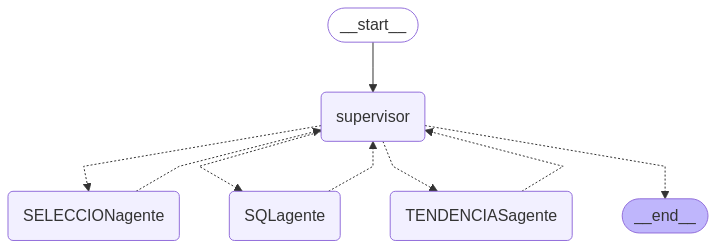

In [9]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
thread_id = "abc124"

def conversar_agente_v2(message, history):
    config = {"configurable": {"thread_id": thread_id}, "recursion_limit": 5000}
    user_msg = HumanMessage(content=message)

    # Usamos .invoke para una ejecución directa, no en streaming
    result = graph.invoke({"messages": [user_msg]}, config=config)

    # Extraemos la respuesta del agente
    respuesta = result["messages"][-1].content

    # Devolvemos el historial actualizado
    return history + [
        {"role": "user", "content": message},
        {"role": "assistant", "content": respuesta},
    ]

# Interfaz con Gradio
gr.ChatInterface(
    fn=conversar_agente_v2,
    chatbot=gr.Chatbot(type="messages", height=400),
    title="Chester Consulting: Impulsando tu Crecimiento 🚀📈🤝",
    description="Investiga las tendencias actuales en tu área de interés y asegúrate de que los programas educativos en los que planeas inscribirte estén alineados con ellas.",
).launch(share=True, debug=True)